# Microstructure Tick Streaks, Density, and Power Law Navigation Research
**Date**: July 2026
**Target**: BTCUSDT Futures

This notebook contains advanced tick-level microstructure research derived from the researcher's observations on derivatives market flow:
1. **Tick Run Identification**: Grouping trades based on consecutive changes in `is_buyer_maker` state to model transactional streaks (runs).
2. **밀도 결정 신호 (Density Decision Signal)**: Analysis of trade-flow density (event sequence vs physical time spacing) and signed volume distributions.
3. **멱함수 신호 & 네비게이션 결정 (Power Law Navigation)**: Implementation of the Closed-Open System model (Z-Open Model) incorporating volume-to-OI ratios and energy capacity limits.

## 1. Setup & API Imports
We import standard analytical libraries and set up paths to import from `research` and `backtests`.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import json
from datetime import datetime

## 2. Tick Run Grouping & Run Identification
We retrieve recent tick-level aggregate trade data from the Binance public REST API. We group consecutive trades that share the same initiator status (`is_buyer_maker` sequence) into streaks. This models buyer/seller aggression flows as sequential 'runs' instead of raw independent events.

In [2]:
symbol = "BTCUSDT"
limit = 1000
url = f"https://fapi.binance.com/fapi/v1/aggTrades?symbol={symbol}&limit={limit}"
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})

with urllib.request.urlopen(req, timeout=15) as resp:
    raw = json.loads(resp.read().decode())

df_trades = pd.DataFrame(raw)
df_trades['time'] = pd.to_datetime(df_trades['T'], unit='ms')
df_trades['price'] = df_trades['p'].astype(float)
df_trades['qty'] = df_trades['q'].astype(float)
df_trades['is_buyer_maker'] = df_trades['m']

# Group by consecutive is_buyer_maker changes (Run Identification)
df_trades['streak_id'] = df_trades['is_buyer_maker'].ne(df_trades['is_buyer_maker'].shift()).cumsum()

# Aggregate into streak summaries
streak_summaries = df_trades.groupby('streak_id').agg({
    'T': 'first',
    'price': ['mean', 'max', 'min', 'first', 'last', 'count'],
    'qty': 'sum',
    'is_buyer_maker': 'first',
}).reset_index()

# Rename columns to match brand_score.ipynb
streak_summaries.columns = ['streak_id', 'time', 'mean_price', 'high', 'low', 'start', 'close', 'count', 'total_qty', 'is_buyer']
print(f"Successfully generated {len(streak_summaries)} streaks from {len(df_trades)} raw trades.")
streak_summaries.head()

Successfully generated 188 streaks from 1000 raw trades.


,streak_id,time,mean_price,high,low,start,close,count,total_qty,is_buyer
0,1,1783735830582,64001.272727,64002.3,64000.1,64002.3,64000.1,11,0.066,True
1,2,1783735830680,64000.100000,64000.1,64000.1,64000.1,64000.1,3,0.023,False
2,3,1783735831294,64000.000000,64000.0,64000.0,64000.0,64000.0,1,0.001,True
3,4,1783735831301,64000.100000,64000.1,64000.1,64000.1,64000.1,2,0.021,False
4,5,1783735832489,64000.000000,64000.0,64000.0,64000.0,64000.0,1,0.068,True


## 밀도 신호 Start

### 3. 밀도 결정 신호 (Density Decision Signal)
We analyze the density of trade flows by comparing the price trajectory across two scales:
1. **Physical Time**: Price mapped to real clock time. Volatility and transaction intensity cause slope spikes.
2. **Event Sequence**: Price mapped to constant event intervals. This isolates the transactional scale.

Additionally, we compute signed quantity flows mapping `is_buyer` maker statuses and analyze their density distribution (KDE & Histogram).

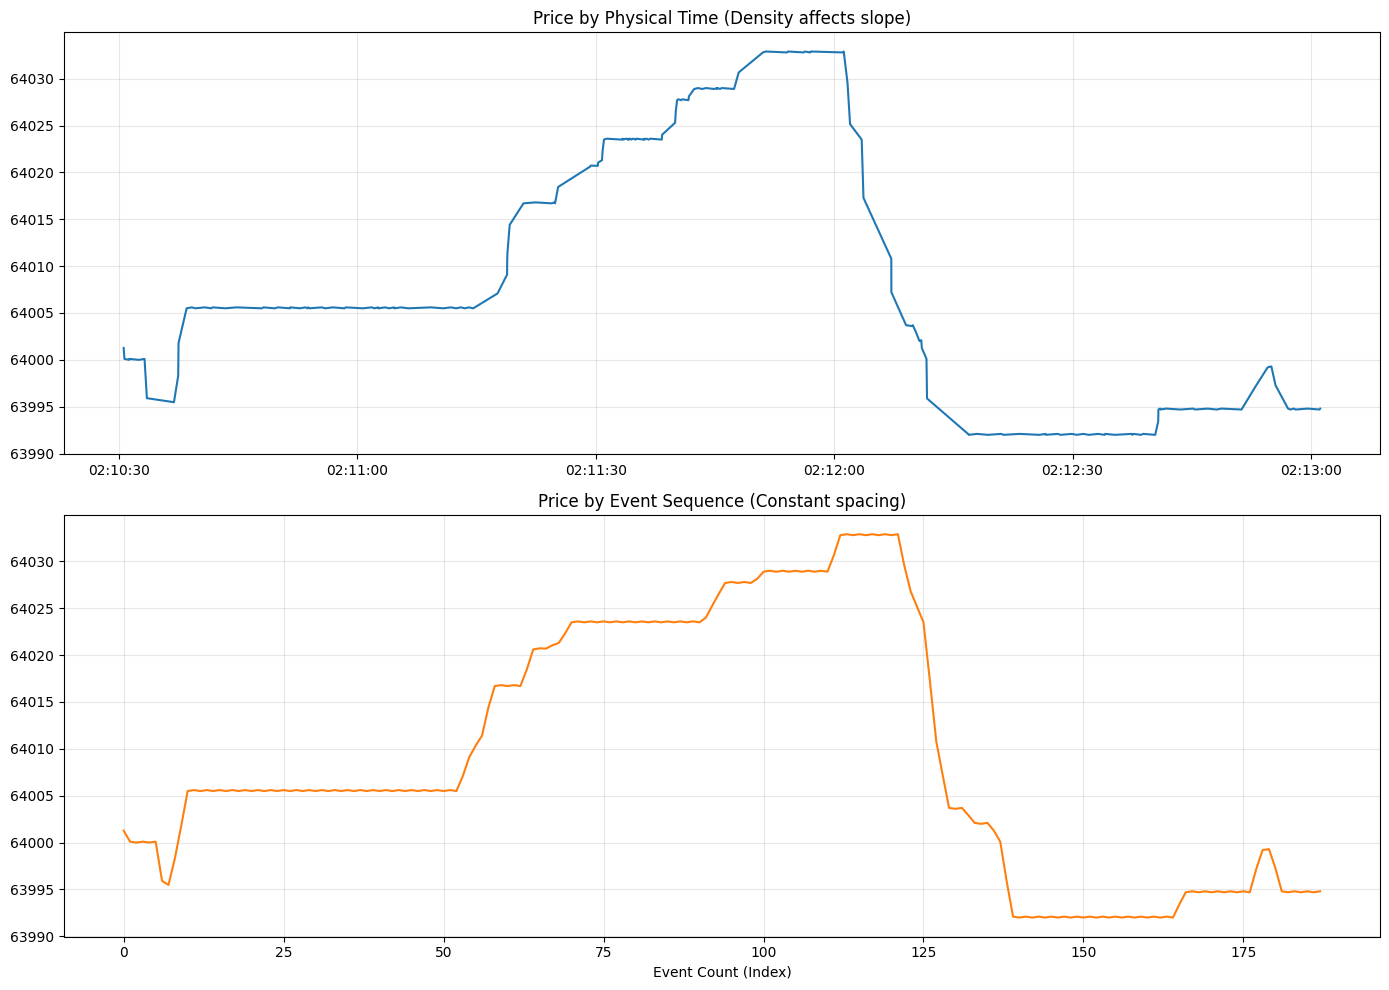

In [3]:
# Signed quantity mapping
# In Binance API, is_buyer_maker=True means seller-initiated (Sell, negative), False means buyer-initiated (Buy, positive)
streak_summaries['signed_total_qty'] = streak_summaries['total_qty'] * streak_summaries['is_buyer'].map({True: -1, False: 1})
streak_summaries['datetime'] = pd.to_datetime(streak_summaries['time'], unit='ms')

# Plot Event vs Physical time scales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharey=True)

ax1.plot(streak_summaries['datetime'], streak_summaries['mean_price'], color='#1f77b4', lw=1.5)
ax1.set_title("Price by Physical Time (Density affects slope)", fontsize=12)
ax1.grid(True, alpha=0.3)

event_index = np.arange(len(streak_summaries))
ax2.plot(event_index, streak_summaries['mean_price'], color='#ff7f0e', lw=1.5)
ax2.set_title("Price by Event Sequence (Constant spacing)", fontsize=12)
ax2.set_xlabel("Event Count (Index)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

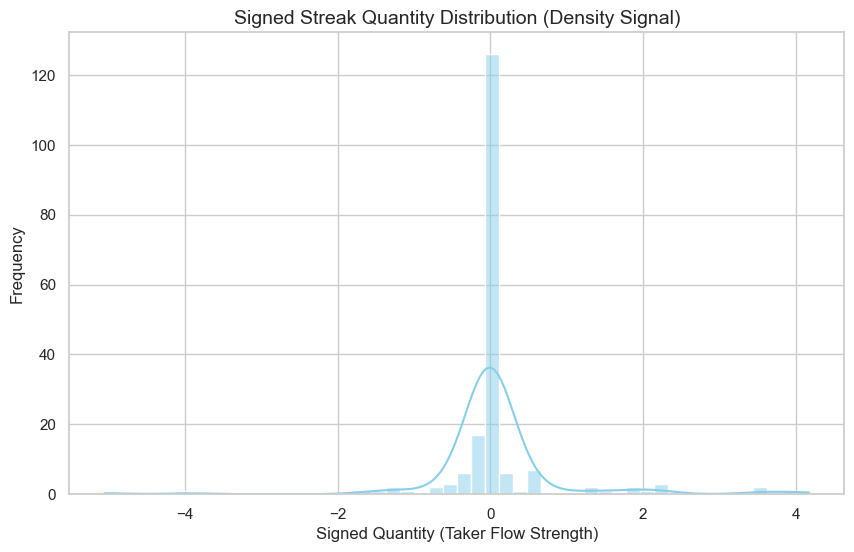

In [4]:
# Data distribution analysis using histplot and KDE
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(streak_summaries['signed_total_qty'], kde=True, color="skyblue", bins=50)
plt.title("Signed Streak Quantity Distribution (Density Signal)", fontsize=14)
plt.xlabel("Signed Quantity (Taker Flow Strength)")
plt.ylabel("Frequency")
plt.show()

## 밀도 신호 End

## 멱함수 신호 Start

### 4. 멱함수에 따른 네비게이션 결정 신호 (Power Law Navigation Decision)
We retrieve 15-minute Klines and Open Interest (OI) historical statistics from Binance Futures. We model the derivatives system as a **Closed-Open System**:
- $ratio = \frac{A}{H}$: Input energy (Volume) to System Capacity (Open Interest) ratio.
- $y_{\text{constrained}} = A \times (1 - (A/H)^k)$: Constrained capacity of the system. As the volume approaches the total open interest pool ($ratio \to 1$), the remaining potential $y$ converges to 0 representing a critical phase barrier.
- $dm_{\text{eff}} = \Delta m \times y_{\text{constrained}}$: Effective directional flow velocity.

We identify critical state transition jumps using the absolute threshold $0.2291$.

In [5]:
symbol = "BTCUSDT"
interval = "15m"
limit = 500

print("Fetching Klines...")
url_k = f"https://fapi.binance.com/fapi/v1/klines?symbol={symbol}&interval={interval}&limit={limit}"
req_k = urllib.request.Request(url_k, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req_k, timeout=15) as resp:
    raw_k = json.loads(resp.read().decode())

print("Fetching Open Interest historical statistics...")
url_oi = f"https://fapi.binance.com/futures/data/openInterestHist?symbol={symbol}&period={interval}&limit={limit}"
req_oi = urllib.request.Request(url_oi, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req_oi, timeout=15) as resp:
    raw_oi = json.loads(resp.read().decode())

df_k = pd.DataFrame(raw_k, columns=['time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'q_av', 'num_trades', 'taker_buy_vol', 'taker_buy_quote_vol', 'ignore'])
df_k = df_k[['time', 'close', 'volume', 'taker_buy_vol']].astype(float)

df_oi_raw = pd.DataFrame(raw_oi)
df_oi_raw['time'] = df_oi_raw['timestamp'].astype(float)
df_oi_raw['oi'] = df_oi_raw['sumOpenInterest'].astype(float)

df_model = pd.merge(df_k, df_oi_raw[['time', 'oi']], on='time')

# 멱함수 및 에너지 제약 조건 연산
k = 50
A = df_model['volume']
H = df_model['oi']
ratio = (A / H).clip(0, 1.1)

y_constrained = A * (1.0 - np.power(ratio, k))

df_model['m'] = df_model['taker_buy_vol'] / df_model['volume']
df_model['dm_eff'] = df_model['m'].diff() * y_constrained

threshold = 0.2291
df_model['long_signal'] = df_model['dm_eff'] > threshold
df_model['short_signal'] = df_model['dm_eff'] < -threshold
df_model['time_dt'] = pd.to_datetime(df_model['time'], unit='ms')

print(f"Generated model outputs. Long signals: {df_model['long_signal'].sum()}, Short signals: {df_model['short_signal'].sum()}")
df_model[['close', 'volume', 'oi', 'dm_eff', 'long_signal', 'short_signal']].tail()

Fetching Klines...
Fetching Open Interest historical statistics...


Generated model outputs. Long signals: 244, Short signals: 254


,close,volume,oi,dm_eff,long_signal,short_signal
495,64103.8,253.807,103852.877,54.278110,True,False
496,64200.1,1061.725,103802.308,72.383582,True,False
497,64019.4,1101.425,103780.401,-313.475960,False,True
498,63979.2,349.175,103604.914,12.391145,True,False
499,63994.8,468.365,103589.823,45.385099,True,False


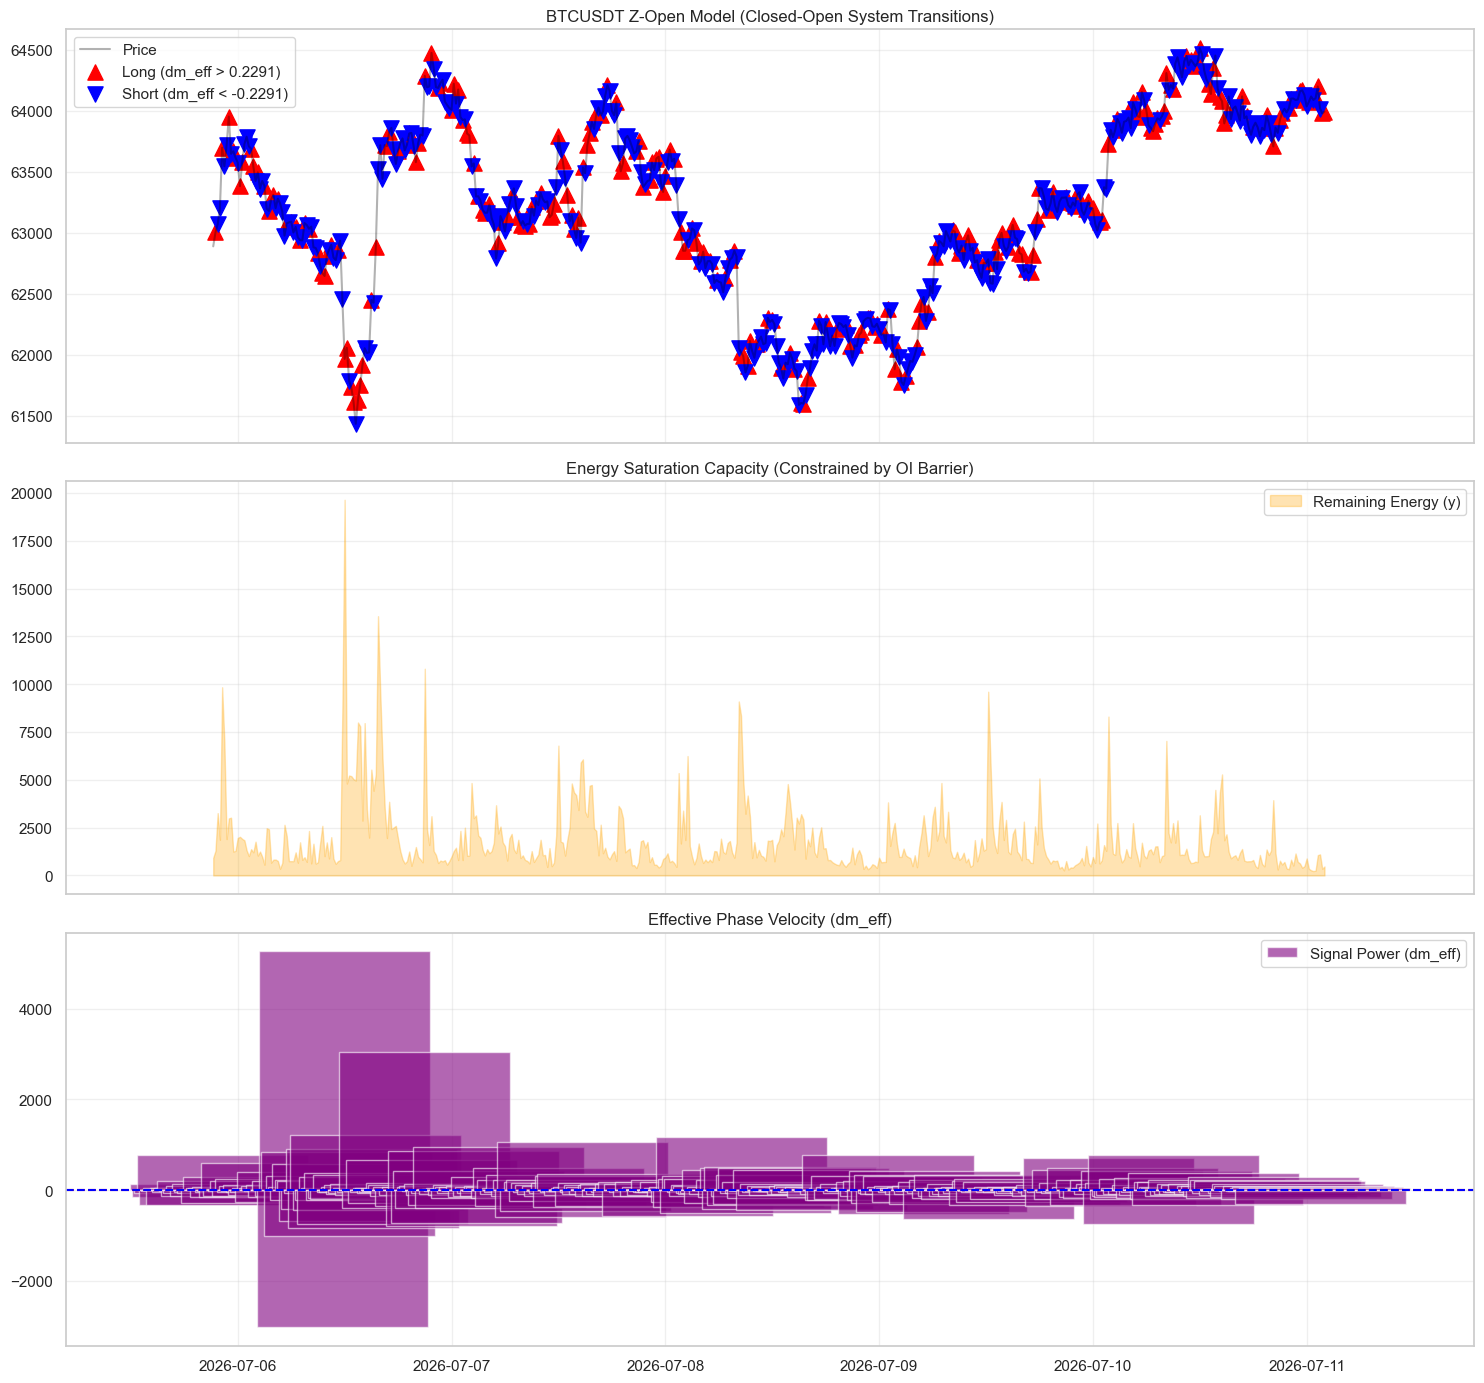

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

# Plot 1: Close Price & Phase transition signals
ax1.plot(df_model['time_dt'], df_model['close'], color='black', alpha=0.3, label='Price')
longs = df_model[df_model['long_signal']]
shorts = df_model[df_model['short_signal']]
ax1.scatter(longs['time_dt'], longs['close'], color='red', marker='^', s=120, label=f'Long (dm_eff > {threshold})')
ax1.scatter(shorts['time_dt'], shorts['close'], color='blue', marker='v', s=120, label=f'Short (dm_eff < -{threshold})')
ax1.set_title(f"BTCUSDT Z-Open Model (Closed-Open System Transitions)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Remaining energy potential (y_constrained)
ax2.fill_between(df_model['time_dt'], 0, y_constrained, color='orange', alpha=0.3, label='Remaining Energy (y)')
ax2.set_title("Energy Saturation Capacity (Constrained by OI Barrier)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Signal Intensity (dm_eff)
ax3.bar(df_model['time_dt'], df_model['dm_eff'], color='purple', alpha=0.6, label='Signal Power (dm_eff)')
ax3.axhline(y=threshold, color='red', linestyle='--')
ax3.axhline(y=-threshold, color='blue', linestyle='--')
ax3.set_title("Effective Phase Velocity (dm_eff)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 멱함수 신호 End

## 5. Summary & Portfolio Integration
By merging tick-level runs (grouping consecutive `is_buyer_maker` changes) with the Closed-Open System (Z-Open) power law framework, we achieve:
1. **Intraday Phase Boundaries**: The Z-Open model identifies points of maximum leverage congestion where phase transition events (reversals or extensions) are highly probable.
2. **Non-time-linear Scale**: Comparing clock-time vs event-sequence trajectories isolates price momentum from high-frequency noise.